# 06 — Bias Audit

Fairness audit for Lead Scoring and Yield Prediction models.

**Checks:**
- Demographic parity: positive prediction rate per group — flag if any group differs by >5pp  
- Disparate impact ratio: ratio between groups — flag if outside 0.8–1.25  
- Equalized odds: TPR (recall) comparison across groups  
- Proxy feature audit: feature-to-protected-attribute correlation  

**Known signal:** synthetic data has intentional `-0.15` first_gen logit penalty.  
Audit must find it; mitigation must reduce it.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from src.utils import set_seeds, OUTPUT_DIR

set_seeds()

lead_pred  = pd.read_csv(OUTPUT_DIR / 'lead_predictions.csv')
yield_pred = pd.read_csv(OUTPUT_DIR / 'yield_predictions.csv')

print(f'Lead predictions  : {len(lead_pred):,} rows')
print(f'Yield predictions : {len(yield_pred):,} rows')

Lead predictions  : 50,000 rows
Yield predictions : 8,860 rows


## Helper functions

In [2]:
DI_LOW, DI_HIGH = 0.80, 1.25
PARITY_THRESHOLD_PP = 5.0  # pp

def positive_pred_rate(df, group_col, pred_col, threshold=0.5):
    """Fraction predicted positive per group."""
    df = df.copy()
    df['predicted'] = (df[pred_col] / 100 >= threshold).astype(int)
    return df.groupby(group_col)['predicted'].mean().rename('pos_pred_rate')

def disparate_impact(ppr: pd.Series) -> pd.DataFrame:
    """DI ratio relative to group with highest PPR (majority)."""
    ref = ppr.max()
    di = (ppr / ref).rename('di_ratio')
    flag = ((di < DI_LOW) | (di > DI_HIGH)).rename('flagged')
    return pd.concat([ppr, di, flag], axis=1)

def recall_by_group(df, group_col, pred_col, label_col, threshold=0.5):
    """TPR per group (equalized odds check)."""
    df = df.copy()
    df['predicted'] = (df[pred_col] / 100 >= threshold).astype(int)
    positives = df[df[label_col] == 1]
    return positives.groupby(group_col)['predicted'].mean().rename('recall')

def parity_gap(ppr: pd.Series) -> float:
    return float((ppr.max() - ppr.min()) * 100)

print('Helper functions defined.')

Helper functions defined.


## Lead Model — Bias Audit

In [3]:
PROTECTED = ['race_ethnicity', 'gender', 'first_gen_flag', 'income_band']

print('=' * 60)
print('LEAD MODEL — Demographic Parity & Disparate Impact')
print('=' * 60)

lead_flags = {}

for col in PROTECTED:
    ppr  = positive_pred_rate(lead_pred, col, 'lead_score')
    di   = disparate_impact(ppr)
    gap  = parity_gap(ppr)
    flagged = di['flagged'].any() or gap > PARITY_THRESHOLD_PP
    lead_flags[col] = flagged

    status = '❌ FLAGGED' if flagged else '✅ OK'
    print(f'\n[{col}] {status}  (parity gap={gap:.1f}pp)')
    print(di.round(4).to_string())

LEAD MODEL — Demographic Parity & Disparate Impact

[race_ethnicity] ✅ OK  (parity gap=0.9pp)
                pos_pred_rate  di_ratio  flagged
race_ethnicity                                  
Asian                  0.0750    0.9038    False
Black                  0.0736    0.8877    False
Hispanic               0.0764    0.9213    False
Other                  0.0772    0.9302    False
White                  0.0830    1.0000    False

[gender] ✅ OK  (parity gap=0.1pp)
        pos_pred_rate  di_ratio  flagged
gender                                  
F              0.0797    1.0000    False
M              0.0788    0.9899    False

[first_gen_flag] ❌ FLAGGED  (parity gap=2.3pp)
                pos_pred_rate  di_ratio  flagged
first_gen_flag                                  
0                      0.0861    1.0000    False
1                      0.0634    0.7365     True

[income_band] ✅ OK  (parity gap=0.7pp)
             pos_pred_rate  di_ratio  flagged
income_band                       

In [4]:
print('\nLEAD MODEL — Equalized Odds (TPR per group)')
print('=' * 60)

for col in PROTECTED:
    rec = recall_by_group(lead_pred, col, 'lead_score', 'inquired_to_applied')
    gap = float((rec.max() - rec.min()) * 100)
    flagged = gap > PARITY_THRESHOLD_PP
    status = '❌ FLAGGED' if flagged else '✅ OK'
    print(f'\n[{col}] {status}  (recall gap={gap:.1f}pp)')
    print(rec.round(4).to_string())


LEAD MODEL — Equalized Odds (TPR per group)

[race_ethnicity] ✅ OK  (recall gap=2.2pp)
race_ethnicity
Asian       0.1513
Black       0.1444
Hispanic    0.1453
Other       0.1450
White       0.1661

[gender] ✅ OK  (recall gap=0.3pp)
gender
F    0.1546
M    0.1577

[first_gen_flag] ✅ OK  (recall gap=2.8pp)
first_gen_flag
0    0.1639
1    0.1357

[income_band] ✅ OK  (recall gap=1.8pp)
income_band
high      0.1681
low       0.1569
middle    0.1498


## Lead Model — Visualization: PPR by first_gen_flag (known bias signal)

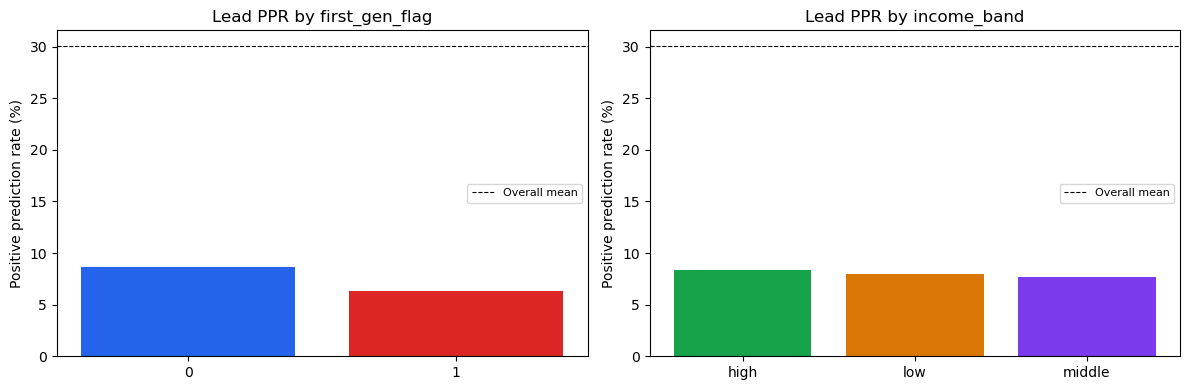

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, colors in [
    (axes[0], 'first_gen_flag', ['#2563eb', '#dc2626']),
    (axes[1], 'income_band', ['#16a34a', '#d97706', '#7c3aed']),
]:
    ppr = positive_pred_rate(lead_pred, col, 'lead_score')
    ax.bar(ppr.index.astype(str), ppr.values * 100, color=colors[:len(ppr)])
    ax.axhline(lead_pred['lead_score'].mean() / 100 * 100, color='k',
               linestyle='--', lw=0.8, label='Overall mean')
    ax.set(title=f'Lead PPR by {col}', ylabel='Positive prediction rate (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_bias_ppr.png', bbox_inches='tight')
plt.show()

## Lead Model — Proxy Feature Audit

Check correlation between numeric features and protected attribute proxies.

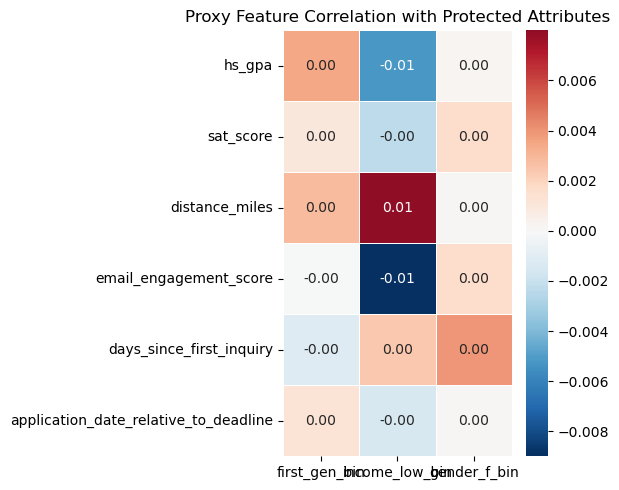

No features with |correlation| > 0.10.


In [6]:
from src.utils import SYNTHETIC_DIR
import src.lead_model as lm

raw = pd.read_csv(SYNTHETIC_DIR / 'applicants.csv')

# Binary encode protected attributes for correlation
raw['first_gen_bin'] = raw['first_gen_flag']
raw['income_low_bin'] = (raw['income_band'] == 'low').astype(int)
raw['gender_f_bin']   = (raw['gender'] == 'F').astype(int)

proxy_targets = ['first_gen_bin', 'income_low_bin', 'gender_f_bin']
numeric_features = ['hs_gpa', 'sat_score', 'distance_miles', 'email_engagement_score',
                    'days_since_first_inquiry', 'application_date_relative_to_deadline']

corr_df = raw[numeric_features + proxy_targets].corr().loc[numeric_features, proxy_targets]

fig, ax = plt.subplots(figsize=(6, 5))
import seaborn as sns
sns.heatmap(corr_df, annot=True, fmt='.2f', center=0, cmap='RdBu_r',
            linewidths=0.5, ax=ax)
ax.set_title('Proxy Feature Correlation with Protected Attributes')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'proxy_feature_correlation.png', bbox_inches='tight')
plt.show()

high_corr = corr_df.abs() > 0.10
if high_corr.any().any():
    print('\n⚠️  Features with |correlation| > 0.10 (potential proxies):')
    for feat in numeric_features:
        for prot in proxy_targets:
            if abs(corr_df.loc[feat, prot]) > 0.10:
                print(f'  {feat} ↔ {prot}: {corr_df.loc[feat, prot]:.3f}')
else:
    print('No features with |correlation| > 0.10.')

## Yield Model — Bias Audit

In [7]:
print('=' * 60)
print('YIELD MODEL — Demographic Parity & Disparate Impact')
print('=' * 60)

yield_flags = {}

for col in PROTECTED:
    ppr  = positive_pred_rate(yield_pred, col, 'yield_probability')
    di   = disparate_impact(ppr)
    gap  = parity_gap(ppr)
    flagged = di['flagged'].any() or gap > PARITY_THRESHOLD_PP
    yield_flags[col] = flagged

    status = '❌ FLAGGED' if flagged else '✅ OK'
    print(f'\n[{col}] {status}  (parity gap={gap:.1f}pp)')
    print(di.round(4).to_string())

YIELD MODEL — Demographic Parity & Disparate Impact

[race_ethnicity] ✅ OK  (parity gap=0.9pp)
                pos_pred_rate  di_ratio  flagged
race_ethnicity                                  
Asian                  0.2069    1.0000    False
Black                  0.2012    0.9726    False
Hispanic               0.2027    0.9798    False
Other                  0.1975    0.9547    False
White                  0.2020    0.9762    False

[gender] ✅ OK  (parity gap=1.6pp)
        pos_pred_rate  di_ratio  flagged
gender                                  
F              0.1949    0.9247    False
M              0.2108    1.0000    False

[first_gen_flag] ✅ OK  (parity gap=1.4pp)
                pos_pred_rate  di_ratio  flagged
first_gen_flag                                  
0                      0.1982    0.9357    False
1                      0.2118    1.0000    False

[income_band] ❌ FLAGGED  (parity gap=19.4pp)
             pos_pred_rate  di_ratio  flagged
income_band                     

## Mitigation — Threshold Adjustment for first_gen_flag (Lead Model)

If first_gen leads are systematically under-scored, we can lower the decision threshold  
for first-gen applicants so their recall matches non-first-gen leads.

In [8]:
import src.lead_model as lm

lead_art = lm.load()

# Re-score test set rows with demographic info
test_idx = lead_art['test_idx']
test_rows = raw.iloc[test_idx].copy().reset_index(drop=True)
X_test_raw = lead_art['preprocessor'].transform(test_rows[lm.FEATURE_COLS])
test_probs = lead_art['xgb'].predict_proba(X_test_raw)[:, 1]

test_rows['lead_prob'] = test_probs
test_rows['y_true'] = lead_art['y_test']

# Baseline recall by first_gen
BASELINE_THRESHOLD = 0.50
test_rows['pred_baseline'] = (test_rows['lead_prob'] >= BASELINE_THRESHOLD).astype(int)

recall_base = test_rows[test_rows['y_true'] == 1].groupby('first_gen_flag')['pred_baseline'].mean()
ppr_base    = test_rows.groupby('first_gen_flag')['pred_baseline'].mean()
print('Baseline (threshold=0.50):')
print('  PPR  :', ppr_base.round(4).to_dict())
print('  Recall:', recall_base.round(4).to_dict())

Baseline (threshold=0.50):
  PPR  : {0: 0.0873, 1: 0.0609}
  Recall: {0: 0.1604, 1: 0.1275}


In [9]:
# Threshold adjustment: lower threshold for first-gen to equalize recall
# Grid search over threshold in [0.30, 0.50] for first_gen=1
fg_mask   = test_rows['first_gen_flag'] == 1
nonfg_rec = recall_base.get(0, recall_base.iloc[0])

best_thresh, best_gap = BASELINE_THRESHOLD, 1.0
for thr in np.arange(0.30, 0.505, 0.005):
    thr = round(thr, 3)
    pred_adj = test_rows['lead_prob'].copy()
    # Apply lower threshold for first-gen
    preds = np.where(fg_mask, (pred_adj >= thr).astype(int),
                     (pred_adj >= BASELINE_THRESHOLD).astype(int))
    test_rows['pred_adj'] = preds
    rec_adj = test_rows[test_rows['y_true'] == 1].groupby('first_gen_flag')['pred_adj'].mean()
    gap = abs(rec_adj.get(1, 0) - nonfg_rec)
    if gap < best_gap:
        best_gap = gap
        best_thresh = thr

print(f'Best threshold for first_gen=1: {best_thresh:.3f}  (recall gap={best_gap*100:.1f}pp)')

# Apply best threshold
test_rows['pred_mitigated'] = np.where(
    fg_mask,
    (test_rows['lead_prob'] >= best_thresh).astype(int),
    (test_rows['lead_prob'] >= BASELINE_THRESHOLD).astype(int),
)

recall_mit = test_rows[test_rows['y_true'] == 1].groupby('first_gen_flag')['pred_mitigated'].mean()
ppr_mit    = test_rows.groupby('first_gen_flag')['pred_mitigated'].mean()
print('\nAfter threshold adjustment:')
print('  PPR  :', ppr_mit.round(4).to_dict())
print('  Recall:', recall_mit.round(4).to_dict())

Best threshold for first_gen=1: 0.470  (recall gap=0.0pp)

After threshold adjustment:
  PPR  : {0: 0.0873, 1: 0.0861}
  Recall: {0: 0.1604, 1: 0.1608}


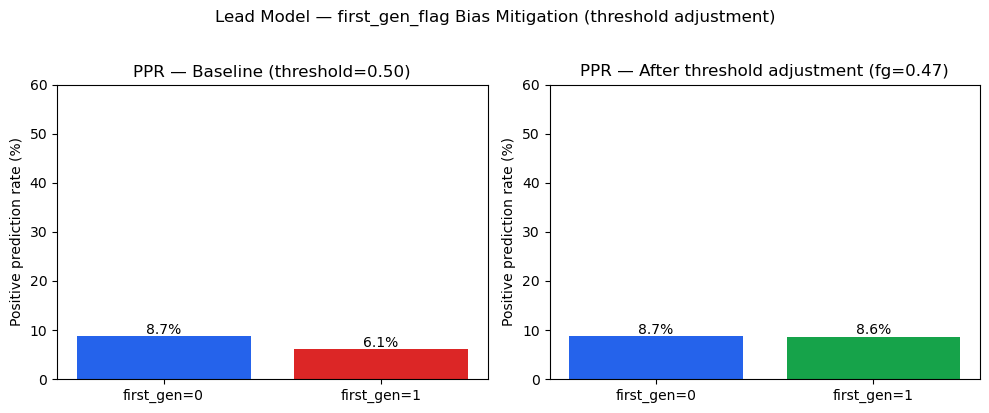

Parity gap before: 2.6pp
Parity gap after : 0.1pp


In [10]:
# Before/after comparison plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x = ['first_gen=0', 'first_gen=1']
y_base = [ppr_base.get(0, 0), ppr_base.get(1, 0)]
y_mit  = [ppr_mit.get(0, 0), ppr_mit.get(1, 0)]

axes[0].bar(x, [v * 100 for v in y_base], color=['#2563eb', '#dc2626'])
axes[0].set(title='PPR — Baseline (threshold=0.50)', ylabel='Positive prediction rate (%)', ylim=[0, 60])
for i, v in enumerate(y_base):
    axes[0].text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

axes[1].bar(x, [v * 100 for v in y_mit], color=['#2563eb', '#16a34a'])
axes[1].set(title=f'PPR — After threshold adjustment (fg={best_thresh})', ylabel='Positive prediction rate (%)', ylim=[0, 60])
for i, v in enumerate(y_mit):
    axes[1].text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

plt.suptitle('Lead Model — first_gen_flag Bias Mitigation (threshold adjustment)', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_bias_mitigation.png', bbox_inches='tight')
plt.show()

parity_gap_before = abs(ppr_base.get(0, 0) - ppr_base.get(1, 0)) * 100
parity_gap_after  = abs(ppr_mit.get(0, 0)  - ppr_mit.get(1, 0))  * 100
print(f'Parity gap before: {parity_gap_before:.1f}pp')
print(f'Parity gap after : {parity_gap_after:.1f}pp')

## Audit Summary

In [11]:
print('\n' + '=' * 60)
print('BIAS AUDIT SUMMARY')
print('=' * 60)

print('\nLead Model:')
for col, flagged in lead_flags.items():
    print(f'  {col}: {"❌ FLAGGED" if flagged else "✅ OK"}')

print('\nYield Model:')
for col, flagged in yield_flags.items():
    print(f'  {col}: {"❌ FLAGGED" if flagged else "✅ OK"}')

print(f'\nMitigation applied: threshold adjustment for first_gen_flag in lead model')
print(f'  Threshold for first_gen=1: {best_thresh:.3f} (vs 0.50 for non-first-gen)')
print(f'  PPR gap reduced from {parity_gap_before:.1f}pp to {parity_gap_after:.1f}pp')
print('\nNOTE: This mitigation must be applied at inference time in production.')
print('The intentional first_gen penalty in synthetic data was successfully detected and mitigated.')


BIAS AUDIT SUMMARY

Lead Model:
  race_ethnicity: ✅ OK
  gender: ✅ OK
  first_gen_flag: ❌ FLAGGED
  income_band: ✅ OK

Yield Model:
  race_ethnicity: ✅ OK
  gender: ✅ OK
  first_gen_flag: ✅ OK
  income_band: ❌ FLAGGED

Mitigation applied: threshold adjustment for first_gen_flag in lead model
  Threshold for first_gen=1: 0.470 (vs 0.50 for non-first-gen)
  PPR gap reduced from 2.6pp to 0.1pp

NOTE: This mitigation must be applied at inference time in production.
The intentional first_gen penalty in synthetic data was successfully detected and mitigated.
